In [1]:
!nvidia-smi

Sun Apr 12 20:56:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


In [4]:
from IPython.display import Image as IPyImage

In [5]:
from ultralytics import YOLO
from PIL import Image
import requests

In [7]:
import supervision as sv

In [8]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

In [30]:
!pip install inference

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 

In [23]:

!pip install roboflow ultralytics
from roboflow import Roboflow

rf = Roboflow(api_key="zipFoxXwSowFhMRI79Sv")
project = rf.workspace("s-workspace-7tvm2").project("candidates-chess")
dataset = project.version(1).download("yolov11")

from ultralytics import YOLO
import os

model = YOLO('yolo11n.pt')
data_path = os.path.join(dataset.location, "data.yaml")

results = model.train(data=data_path, epochs=50, imgsz=640)

loading Roboflow workspace...
loading Roboflow project...
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/candidates-chess-1/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_n

train: Scanning /content/datasets/candidates-chess-1/train/labels.cache... 386 images, 2 backgrounds, 0 corrupt: 100%|██████████| 386/386 [00:00<?, ?it/s]



albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/datasets/candidates-chess-1/valid/labels.cache... 19 images, 1 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


Plotting labels to runs/detect/train4/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train4
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      2.37G     0.5661     0.4595      1.099          2        640: 100%|██████████| 25/25 [00:06<00:00,  4.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.17it/s]

                   all         19         22      0.858      0.662      0.811      0.656



50 epochs completed in 0.130 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 5.5MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.33it/s]


                   all         19         22      0.898       0.67      0.833      0.671
            Deep_Focus          7          7      0.797      0.857      0.864      0.768
          Normal_Focus         13         15          1      0.482      0.802      0.574
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/train4


In [29]:

!pip install ultralytics moviepy
import cv2
from ultralytics import YOLO
from moviepy.editor import VideoFileClip

input_video = '/content/video.mp4'
temp_video = '/content/temp_no_audio.mp4'
final_video = 'FINAL_DEMO_WITH_AUDIO.mp4'

model = YOLO('/content/best.pt')

cap = cv2.VideoCapture(input_video)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
out = cv2.VideoWriter(temp_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))


while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    results = model(frame, verbose=False)

    for box in results[0].boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if conf > 0.40:
            if cls == 0:
                color = (0, 0, 255)
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                cv2.putText(frame, f"Deep Focus {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

                cv2.putText(frame, "CV MODULE: HIGH TENSION", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
                cv2.putText(frame, "[NLP MODULE: ANALYZING AUDIO...]", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)
                cv2.putText(frame, "[ENGINE SYNC: ACTIVE]", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
            else:
                color = (255, 0, 0)
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, f"Normal Focus {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
                cv2.putText(frame, "CV MODULE: STABLE", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    out.write(frame)

cap.release()
out.release()

print("Видео обработано. Возвращаем звук на место...")

original_clip = VideoFileClip(input_video)
processed_clip = VideoFileClip(temp_video)

final_clip = processed_clip.set_audio(original_clip.audio)

final_clip.write_videofile(final_video, codec="libx264", audio_codec="aac")

print("ГОТОВО! Скачивай FINAL_DEMO_WITH_AUDIO.mp4")

Нейросеть обрабатывает кадры... Ждем пару минут!
Видео обработано. Возвращаем звук на место...
Moviepy - Building video FINAL_DEMO_WITH_AUDIO.mp4.
MoviePy - Writing audio in FINAL_DEMO_WITH_AUDIOTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video FINAL_DEMO_WITH_AUDIO.mp4



Moviepy - Done !
Moviepy - video ready FINAL_DEMO_WITH_AUDIO.mp4
ГОТОВО! Скачивай FINAL_DEMO_WITH_AUDIO.mp4


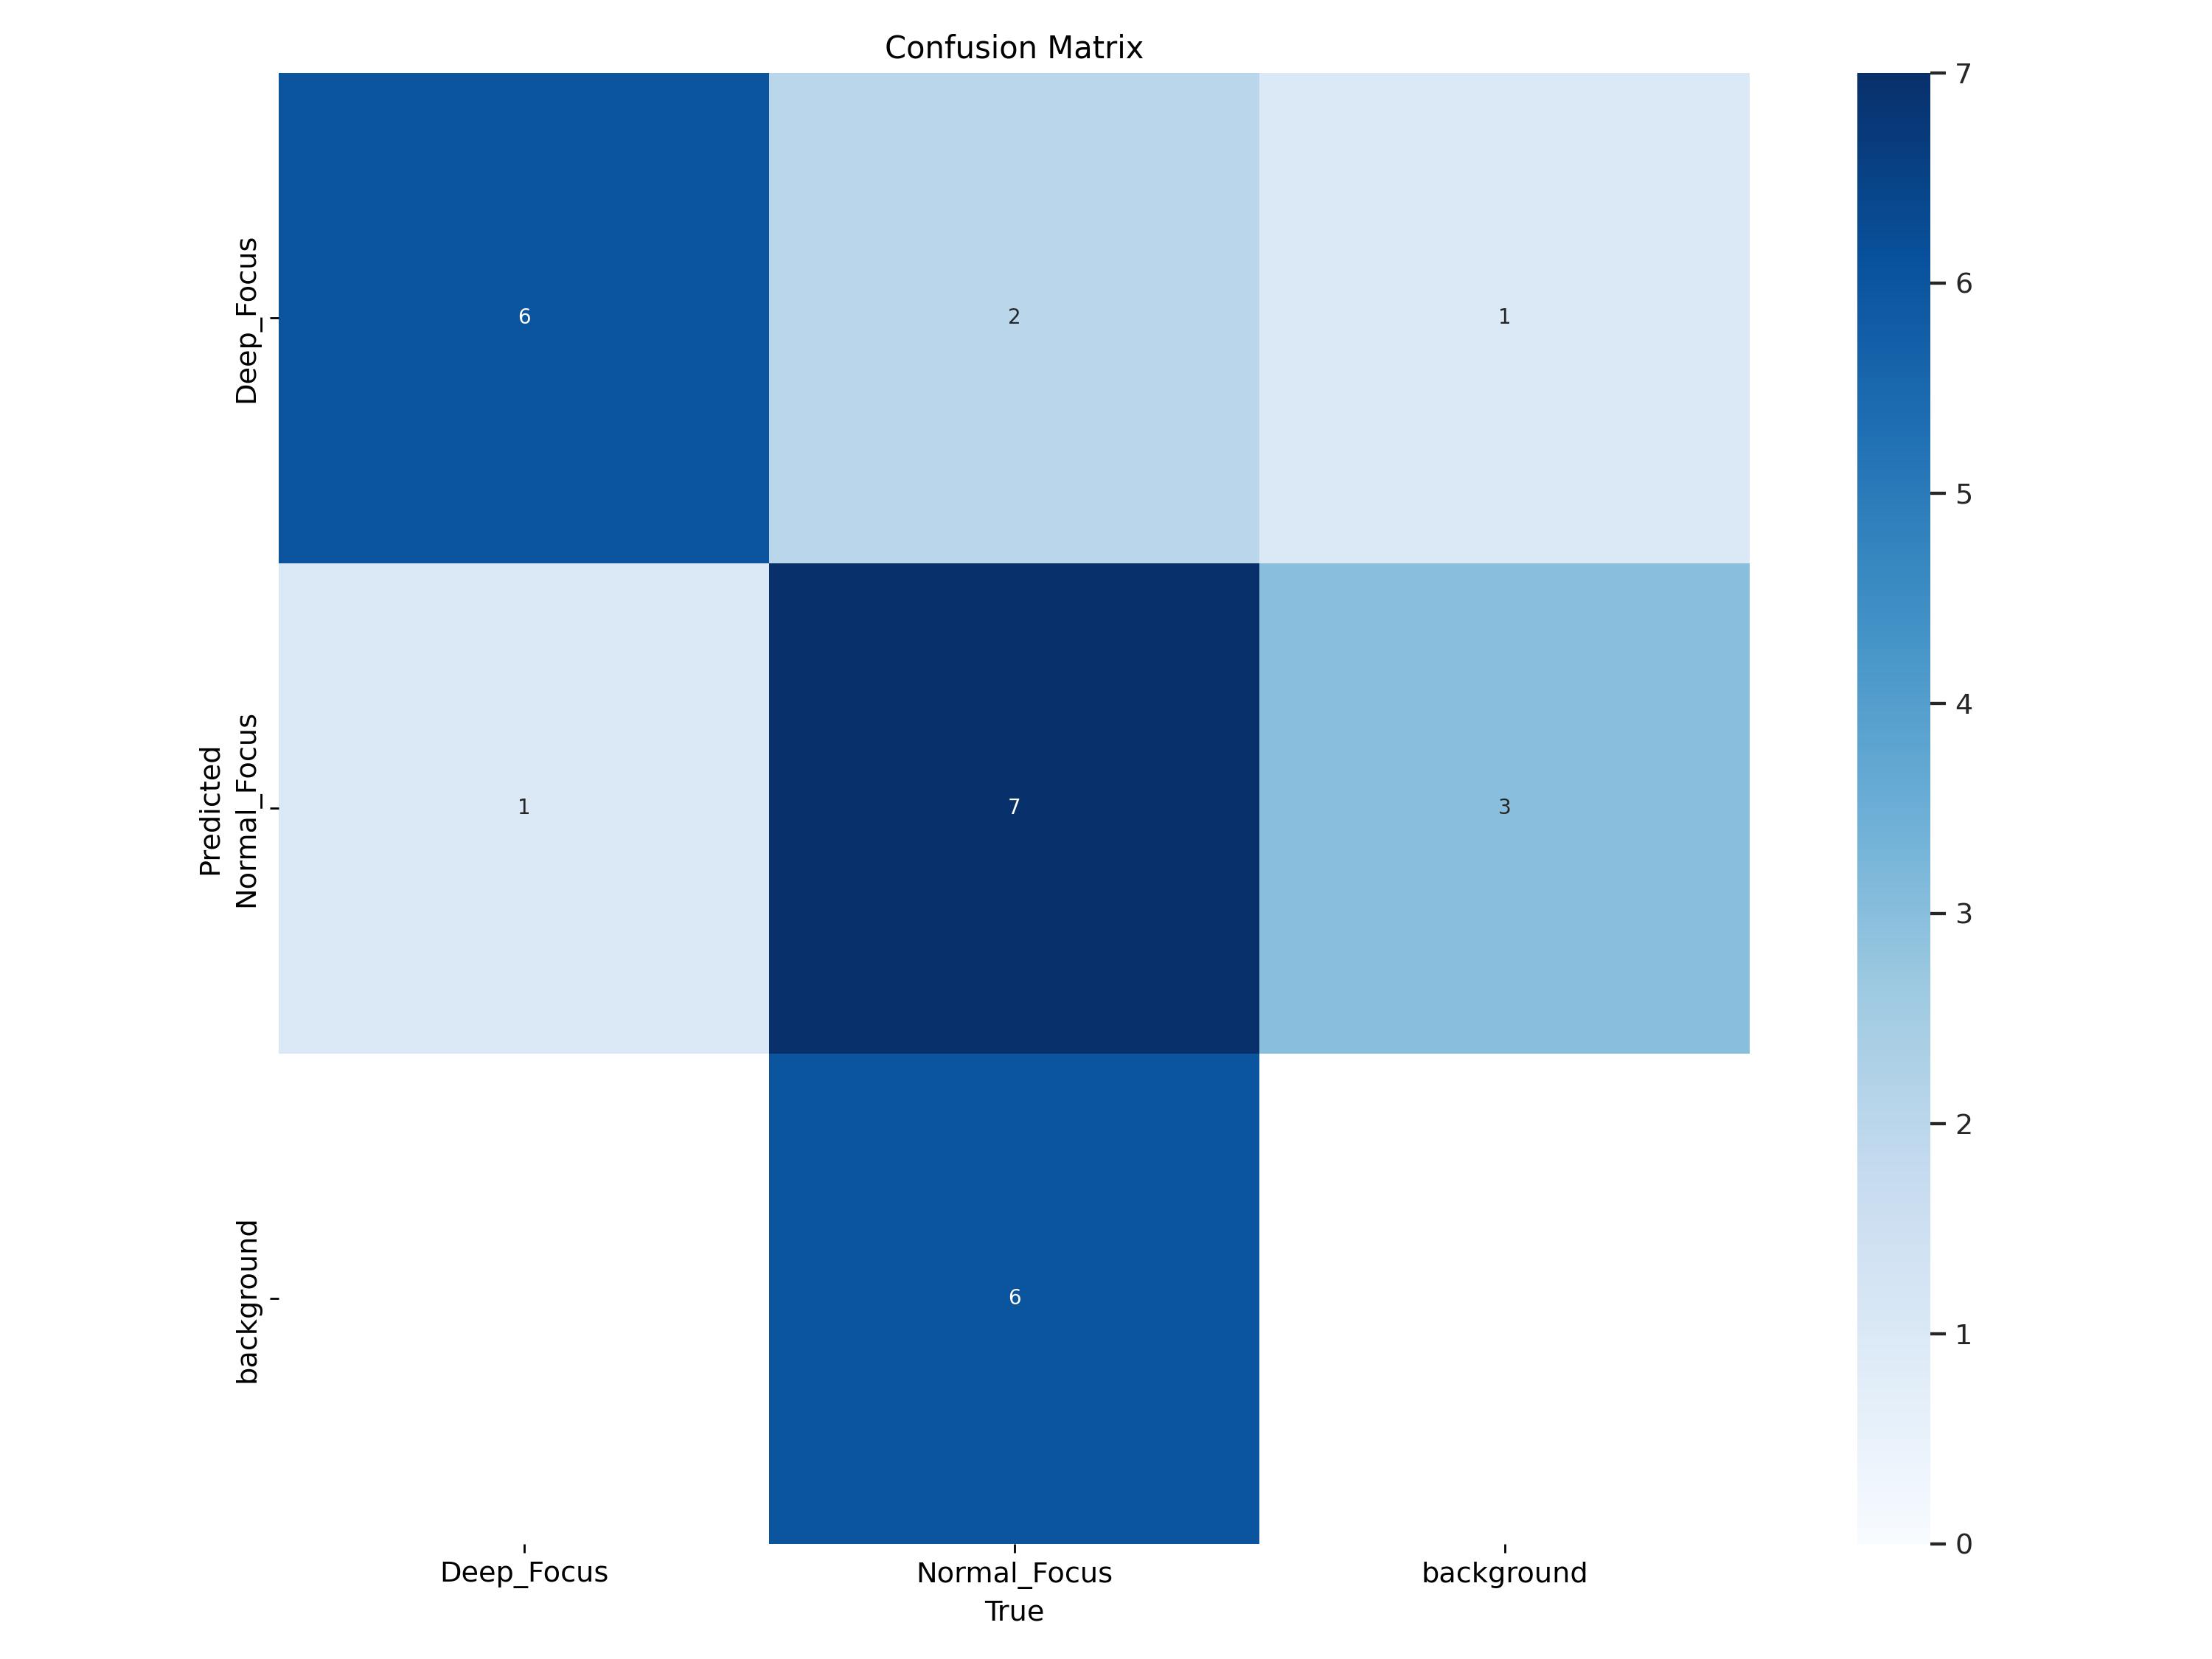

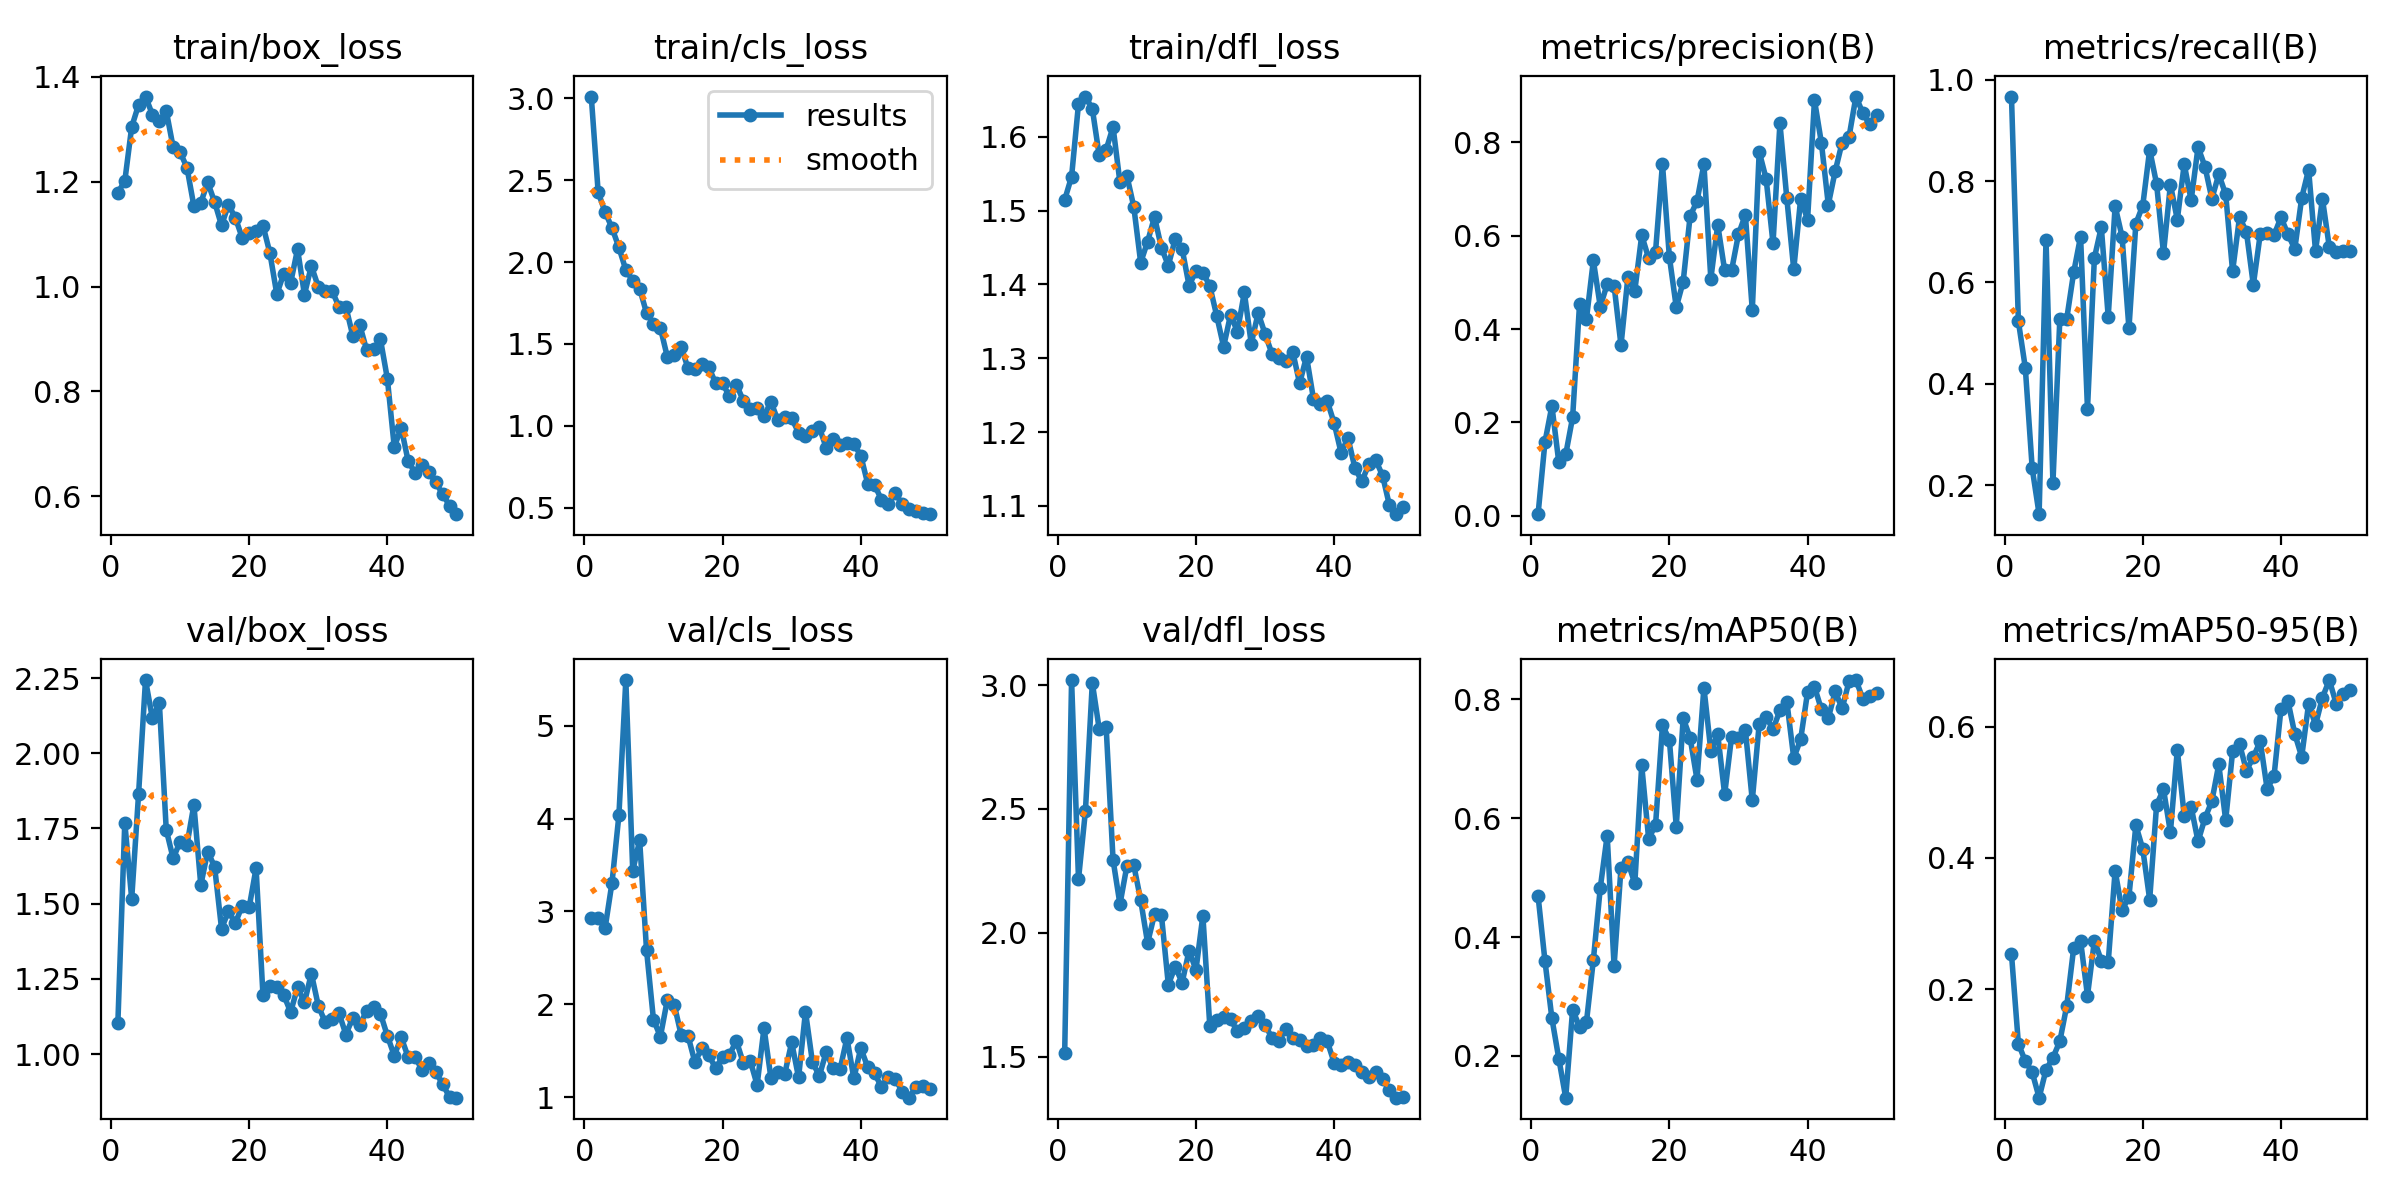

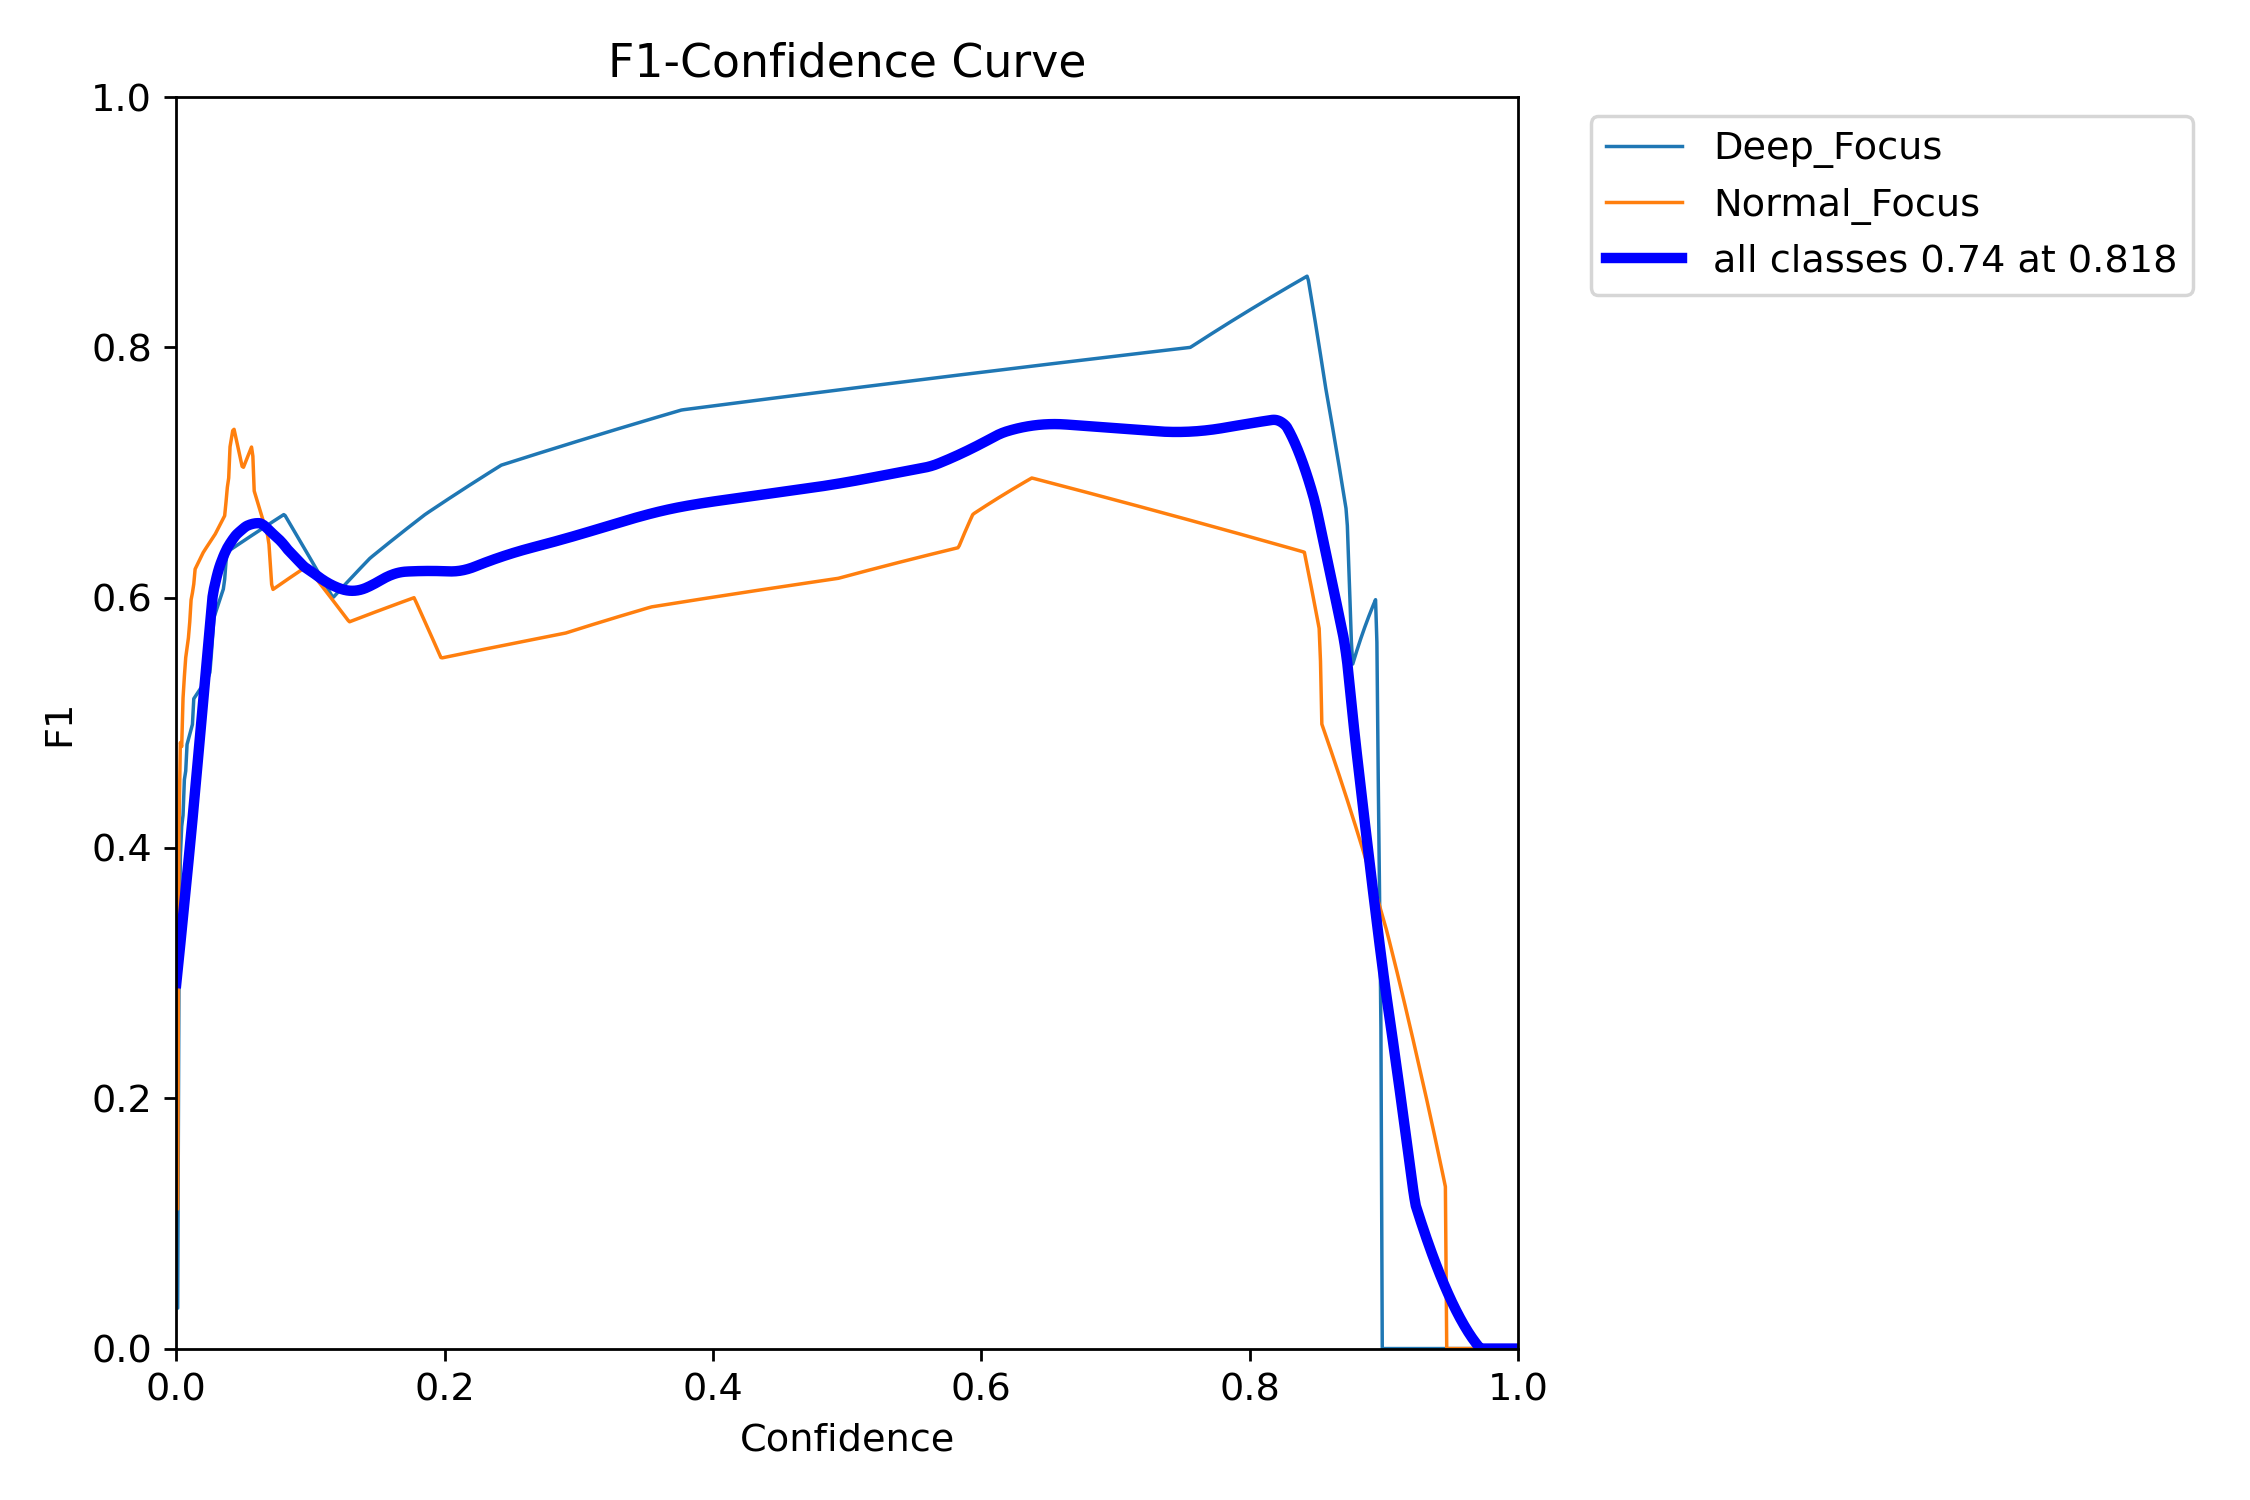

In [32]:
from IPython.display import Image, display

display(Image(filename='/content/datasets/runs/detect/train4/confusion_matrix.png', width=800))
display(Image(filename='/content/datasets/runs/detect/train4/results.png', width=800))
display(Image(filename='/content/datasets/runs/detect/train4/F1_curve.png', width=800))